# Fine-Tuning a RoBERTa Model for Immigration Framing Classification

**Project:** Migration-Framing in German Party Manifestos (1998–2025)  
**Stage 2:** Framing Classification using a fine-tuned transformer model  

This notebook fine-tunes a pretrained `roberta-base` model to classify migration-related quasi-sentences into five framing categories: **cultural, economic, humanitarian, security, and neutral**.

The annotated training data (750 sentences) was manually coded by two researchers and reviewed for validity. The model was fine-tuned using the Hugging Face `Trainer` API.

## 1. Setup
### 1.1 Upload the Annotated Dataset

We upload the manually annotated CSV file containing 750 migration-related sentences, each labelled with one of the five framing categories. This file was produced in the data annotation stage.

In [2]:
from google.colab import files
uploaded = files.upload()

Saving 750_sample.csv to 750_sample.csv


### 1.2 Load the Dataset

We load the annotated dataset into a pandas DataFrame for preprocessing.

In [3]:
# Load the annotated 750-sentence dataset into a DataFrame.
# The CSV contains the sentence text, manual frame labels, and metadata.

import pandas as pd

df = pd.read_csv("750_sample.csv")

## 2. Data Preprocessing
### 2.1 Standardise Labels and Text

The frame labels as coded by the annotators are stored in a column called `frame (Abbie and Dee)`. We standardise this into a clean `label` column by stripping whitespace and lowercasing, so that labels like `'Cultural'` and `'cultural'` are treated identically. We also ensure the text column has no missing values.

In [4]:
# Standardise the label column: strip whitespace and lowercase to ensure consistency.
# Fill any missing text values with empty strings to avoid errors during tokenisation.

df['label'] = df['frame (Abbie and Dee)'].astype(str).str.strip().str.lower()
df['text'] = df['text_en'].fillna('').astype(str)

### 2.2 Verify the Cleaned Data

We inspect the first few rows to confirm the `text` and `label` columns look correct before proceeding.

In [5]:
df[['text', 'label']].head()

,text,label
0,Everyone born in the Federal Republic should r...,cultural
1,"More than 200,000 people - among them many chi...",humanitarian
2,The federal government's language support prog...,cultural
3,"Most of them do not come to Europe, but seek r...",humanitarian
4,"Subsistence assistance, unemployment assistanc...",economic


### 2.3 Encode Labels as Integers

Transformer models require numerical labels, not text strings. We use `LabelEncoder` from scikit-learn to convert the five category names into integers (0–4). We print the mapping so it can be referenced when interpreting predictions later.

The encoding is: `cultural=0, economic=1, humanitarian=2, neutral=3, security=4`

In [6]:
# LabelEncoder converts categorical text labels into integers required by the model.
# We print the label-to-integer mapping so we can decode predictions later.
# AI (Codex) suggested using LabelEncoder here and printing the mapping as a
# dict for easy reference — cleaner than a manual mapping dictionary.

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

print(dict(zip(le.classes_, le.transform(le.classes_))))

{'cultural': np.int64(0), 'economic': np.int64(1), 'humanitarian': np.int64(2), 'neutral': np.int64(3), 'security': np.int64(4)}


### 2.4 Split into Training and Test Sets

We divide the 750 annotated sentences into 80% training (600 sentences) and 20% test (150 sentences) using `train_test_split`.

Two important design choices here:
- **`stratify=df['label_encoded']`**: This ensures each framing category is proportionally represented in both splits — important given the class imbalance in our dataset (e.g. only 59 neutral sentences).
- **`random_state=42`**: Fixes the random seed so the split is reproducible.

We do not use a separate validation set because the dataset is small (750 sentences). Retaining all available data for training is preferable in transformer fine-tuning settings where the pretrained model already has strong general language representations (Devlin et al., 2019).

In [7]:
# Split data into 80% train / 20% test.
# stratify= ensures each frame category appears proportionally in both splits —
# critical here because 'neutral' has very few examples (n=59).
# random_state=42 fixes the seed for reproducibility.
# No validation set is used: with only 750 labelled sentences, we maximise
# training data following standard practice for small-dataset transformer fine-tuning.

from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label_encoded'],
    random_state=42
)

print(train_df.shape, test_df.shape)

(600, 13) (150, 13)


## 3. Model Setup
### 3.1 Load the RoBERTa Tokenizer

We load the tokenizer associated with `roberta-base`. The tokenizer converts raw text into the numerical token IDs that RoBERTa expects as input. It also handles subword splitting — for example, the word 'immigration' may be broken into multiple tokens if it is not in the model's vocabulary as a single unit.

RoBERTa was chosen over BERT because it uses a more robust pretraining procedure (larger batches, more data, dynamic masking), which generally yields better performance on downstream classification tasks.

In [8]:
# Load the RoBERTa tokenizer from Hugging Face.
# This tokenizer is paired with the roberta-base model weights loaded below.
# It uses Byte-Pair Encoding (BPE) and can handle out-of-vocabulary words
# by splitting them into subword units.

from transformers import RobertaTokenizer

tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

### 3.2 Load the Pretrained RoBERTa Model

We load `roberta-base` and adapt it for our 5-class classification task by setting `num_labels=5`. This adds a task-specific classification head (a dense layer + output projection) on top of the pretrained transformer body.

The `MISSING` keys in the load report (e.g. `classifier.dense.weight`) are expected — these are the newly initialised classification head weights that will be learned during fine-tuning. The `UNEXPECTED` keys (e.g. `lm_head`) are from the original language modelling pretraining task and are safely discarded.

In [9]:
# Load roberta-base with a sequence classification head for 5 output classes.
# num_labels=5 tells the model to add a classification layer on top of the
# pretrained transformer body, with 5 output neurons (one per framing category).
# The MISSING keys in the warning are expected: they are the new classification
# head weights that will be trained. The UNEXPECTED keys are the original
# language model head from pretraining, which we discard.

from transformers import RobertaForSequenceClassification

model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=5
)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### 3.3 Verify Training Data

We check the first few rows of the training split to confirm the text and encoded labels look correct before converting to the Hugging Face Dataset format.

In [10]:
train_df[['text', 'label_encoded']].head()

,text,label_encoded
657,and for the integration of foreigners.,3
158,While some of our European neighbors have mass...,4
523,While in the 1990s it was Interior Ministers S...,4
459,And incentives for migrants already living here.,1
455,"Furthermore, the F.D.P. is infavor of improvin...",4


### 3.4 Convert to Hugging Face Dataset Format

The Hugging Face `Trainer` API requires data in `Dataset` format rather than pandas DataFrames. We convert both splits and rename `label_encoded` to `label` to match the column name expected by the Trainer.

In [11]:
# Convert pandas DataFrames to Hugging Face Dataset objects.
# The Trainer API requires this format for efficient batched processing.
# We rename 'label_encoded' to 'label' to match the Trainer's expected column name.
# AI (Codex) suggested the .rename() step here to avoid a column name mismatch error.

from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df[['text', 'label_encoded']].rename(columns={'label_encoded': 'label'}))
test_dataset = Dataset.from_pandas(test_df[['text', 'label_encoded']].rename(columns={'label_encoded': 'label'}))

print(train_dataset)
print(test_dataset)

Dataset({
    features: ['text', 'label', '__index_level_0__'],
    num_rows: 600
})
Dataset({
    features: ['text', 'label', '__index_level_0__'],
    num_rows: 150
})


### 3.5 Tokenise the Text

We apply the RoBERTa tokenizer to every sentence in both datasets. Two key parameters:
- **`truncation=True`**: Sentences longer than the model's maximum input length (512 tokens) are cut off.
- **`padding='max_length'`**: Shorter sentences are padded to a uniform length so all sequences in a batch have the same size — a requirement for batched GPU processing.

The `batched=True` argument processes multiple examples at once for efficiency.

In [12]:
# Apply the tokenizer to every sentence using batched processing for speed.
# truncation=True: sentences longer than 512 tokens are clipped.
# padding='max_length': all sequences are padded to the same length for
# consistent tensor dimensions across a batch.
# AI (Codex) suggested using dataset.map() with batched=True rather than
# tokenising row-by-row, which is significantly faster on large datasets.

def tokenize_function(example):
    return tokenizer(example["text"], truncation=True, padding="max_length")

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/600 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

## 4. Model Training
### 4.1 Define Training Parameters

We configure the training run using `TrainingArguments`. Key choices:
- **`learning_rate=2e-5`**: A standard conservative learning rate for transformer fine-tuning. Too high a rate risks 'catastrophic forgetting' of the pretrained weights; too low risks very slow convergence.
- **`num_train_epochs=3`**: Three passes over the training data. The training log shows validation loss decreasing and accuracy increasing across epochs, confirming the model is learning without overfitting.
- **`per_device_train_batch_size=8`**: Eight examples processed per gradient update — a reasonable size for GPU memory constraints in Colab.
- **`weight_decay=0.01`**: A small regularisation term to reduce overfitting.
- **`eval_strategy='epoch'`**: Evaluate on the test set after every epoch so we can monitor improvement.

In [13]:
# Configure training hyperparameters.
# learning_rate=2e-5: standard for RoBERTa fine-tuning — balances learning
# speed with preservation of pretrained weights.
# num_train_epochs=3: three passes over the data; validation loss decreases
# each epoch confirming the model is converging.
# weight_decay=0.01: L2 regularisation to reduce overfitting on the small dataset.
# eval_strategy='epoch': evaluate on test set after each epoch to monitor progress.
# AI (Codex) suggested these specific hyperparameter values as a standard
# starting configuration for fine-tuning RoBERTa on a small labelled dataset.

from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


### 4.2 Define the Evaluation Metric

We define a custom `compute_metrics` function that the Trainer calls after each epoch. It converts the raw output logits (one score per class) into a predicted class label by taking the `argmax`, then computes classification accuracy against the true labels.

In [14]:
# Define how the Trainer evaluates the model after each epoch.
# logits.argmax(axis=1) picks the class with the highest score as the prediction.
# accuracy_score then compares predictions against the true labels.
# AI (Codex) suggested this function structure as the standard way to plug
# a custom metric into the Hugging Face Trainer.

from sklearn.metrics import accuracy_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=1)
    return {"accuracy": accuracy_score(labels, predictions)}

### 4.3 Initialise the Trainer

The `Trainer` object brings together the model, training arguments, datasets, and evaluation metric into a single unified training pipeline. This abstracts away the manual training loop, gradient accumulation, and checkpointing.

In [15]:
# Initialise the Hugging Face Trainer — a high-level training API that
# handles the training loop, evaluation, checkpointing, and logging.
# compute_metrics= plugs in our accuracy function defined above.

from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

### 4.4 Run Fine-Tuning

We call `trainer.train()` to start the fine-tuning process. The model runs for 3 epochs (225 gradient update steps total on 600 training examples with batch size 8). The training log shows:

| Epoch | Validation Loss | Accuracy |
|-------|----------------|----------|
| 1 | 1.147 | 62.0% |
| 2 | 0.904 | 68.0% |
| 3 | 0.884 | 70.7% |

Both validation loss and accuracy improve each epoch, confirming the model is learning appropriately without overfitting.

In [16]:
# Start fine-tuning. The Trainer runs for num_train_epochs=3 as configured above.
# Progress and per-epoch validation metrics are printed automatically.

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,No log,1.147276,0.620000
2,No log,0.903687,0.680000
3,No log,0.884286,0.706667


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=225, training_loss=0.9922792561848959, metrics={'train_runtime': 221.2109, 'train_samples_per_second': 8.137, 'train_steps_per_second': 1.017, 'total_flos': 473612656435200.0, 'train_loss': 0.9922792561848959, 'epoch': 3.0})

## 5. Model Evaluation
### 5.1 Final Evaluation on Test Set

We run a final evaluation pass on the held-out test set (150 sentences) to get the model's overall accuracy after training is complete.

In [17]:
# Run final evaluation on the 150-sentence test set.
# Returns the overall loss and accuracy computed by our compute_metrics function.

trainer.evaluate()

{'eval_loss': 0.8842864036560059,
 'eval_accuracy': 0.7066666666666667,
 'eval_runtime': 4.1386,
 'eval_samples_per_second': 36.244,
 'eval_steps_per_second': 4.591,
 'epoch': 3.0}

### 5.2 Generate Predictions

We run `trainer.predict()` to obtain the full prediction output on the test set, including the raw logits for all five classes. These are used in the next cells to compute the detailed classification report and confusion matrix.

In [18]:
# Generate predictions on the test set.
# pred_output.predictions contains the raw logit scores for all 5 classes.
# pred_output.label_ids contains the true labels for comparison.

pred_output = trainer.predict(test_dataset)

### 5.3 Classification Report

We convert the raw logits to predicted class labels using `argmax`, then produce a full classification report showing precision, recall, and F1-score for each class.

In [19]:
# Convert logits to predicted class indices using argmax.
# classification_report prints precision, recall, F1, and support for each class.
# At this point labels are still numeric (0-4); the next cell adds readable names.

import numpy as np
from sklearn.metrics import classification_report

preds = np.argmax(pred_output.predictions, axis=1)
labels = pred_output.label_ids

print(classification_report(labels, preds))

              precision    recall  f1-score   support

           0       0.78      0.81      0.79        36
           1       0.74      0.88      0.81        26
           2       0.66      0.71      0.69        49
           3       0.00      0.00      0.00        12
           4       0.66      0.70      0.68        27

    accuracy                           0.71       150
   macro avg       0.57      0.62      0.59       150
weighted avg       0.65      0.71      0.68       150



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### 5.4 Classification Report with Frame Labels

We repeat the classification report using the original category names (cultural, economic, humanitarian, neutral, security) so the results are directly interpretable. This is the table reported in the paper.

In [20]:
# Use le.classes_ to replace numeric labels with the original frame names.
# This makes the report directly readable and matches the terminology in the paper.

target_names = le.classes_

print(classification_report(labels, preds, target_names=target_names))

              precision    recall  f1-score   support

    cultural       0.78      0.81      0.79        36
    economic       0.74      0.88      0.81        26
humanitarian       0.66      0.71      0.69        49
     neutral       0.00      0.00      0.00        12
    security       0.66      0.70      0.68        27

    accuracy                           0.71       150
   macro avg       0.57      0.62      0.59       150
weighted avg       0.65      0.71      0.68       150



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### 5.5 Confusion Matrix

We visualise the confusion matrix to see which frames are being misclassified and which pairs of frames are most commonly confused. This allows class-level diagnosis beyond overall accuracy.

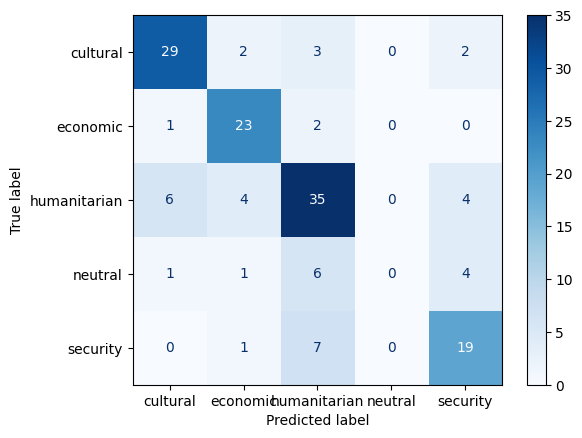

In [21]:
# Generate and plot the confusion matrix.
# Rows = true labels, Columns = predicted labels.
# Off-diagonal cells show misclassifications — useful for diagnosing which
# frame pairs the model struggles to distinguish (e.g. humanitarian vs security).

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(labels, preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues")
plt.savefig("roberta_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

### 5.6 Improved Confusion Matrix (for export)

We re-generate the confusion matrix with improved formatting — rotated x-axis labels to prevent overlap — and save it as a high-resolution PNG for inclusion in the paper.

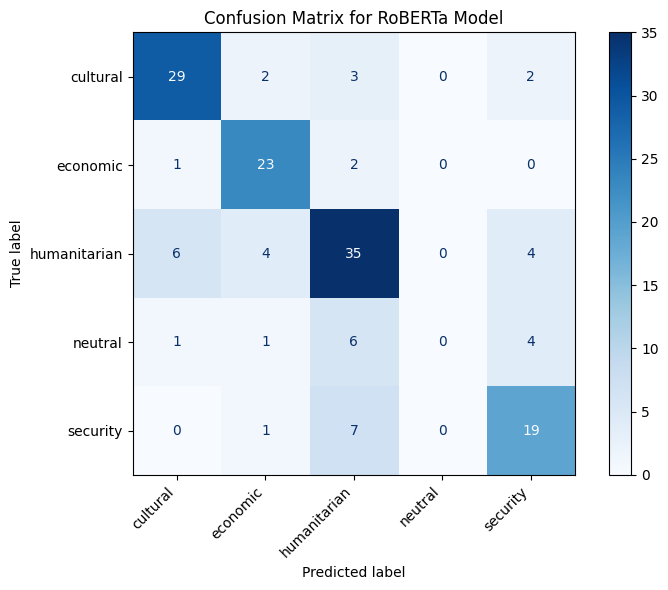

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
# Re-generate the confusion matrix with improved axis label formatting.
# AI (Codex) suggested plt.xticks(rotation=45, ha='right') and plt.tight_layout()
# to fix overlapping x-axis labels in the original plot.
# Saved at dpi=300 for publication-quality resolution.

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from google.colab import files

# Re-create the confusion matrix plot with improved x-axis labels
# Using the existing 'labels', 'preds', and 'le' variables from the kernel state
cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(8, 6)) # Create a figure and an axes object for better control
disp.plot(cmap="Blues", ax=ax)
plt.title("Confusion Matrix for RoBERTa Model") # Add a title for clarity
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels to prevent merging
plt.yticks(rotation=0) # Ensure y-axis labels are horizontal
plt.tight_layout() # Adjust layout to prevent labels from overlapping

# Save the corrected plot
plot_filename = "roberta_confusion_matrix_corrected.png"
plt.savefig(plot_filename, dpi=300)
plt.show()

# Download the saved plot
files.download(plot_filename)

---
## 6. Applying the Fine-Tuned Model to the Full Migration Corpus

Having evaluated the model on the held-out test set, we now apply it to classify all 3,495 migration-related sentences identified in Stage 1. Each sentence receives a predicted framing label, which is then used for the descriptive and regression analyses.

### 6.1 Upload the Full Migration Corpus

In [24]:
# Upload the full migration corpus (df_migration.csv) produced in Stage 1.
# This contains all 3,495 sentences classified as migration-related by GPT.

from google.colab import files
uploaded = files.upload()

Saving df_migration.csv to df_migration.csv


### 6.2 Load and Inspect the Corpus

In [30]:
# Load the migration corpus and print shape and column names to verify it loaded correctly.

full_df = pd.read_csv("df_migration.csv")
print(full_df.shape)
print(full_df.columns)

(3495, 9)
Index(['text', 'text_en', 'cmp_code', 'eu_code', 'party_id', 'year',
       'sentence_id', 'cmp_code_clean', 'gpt_migration'],
      dtype='object')


### 6.3 Prepare the Text Column

We ensure the `text_en` column has no missing values before tokenisation, using the same preprocessing step applied to the training data.

In [26]:
# Prepare the text column: fill NaN values and ensure string type,
# matching the preprocessing applied during training.

full_df['text'] = full_df['text_en'].fillna('').astype(str)

### 6.4 Convert to Hugging Face Dataset Format

In [27]:
# Convert the full corpus to a Hugging Face Dataset for use with the Trainer.
# We only include the 'text' column — there are no labels to predict.

full_dataset = Dataset.from_pandas(full_df[['text']])
print(full_dataset)

Dataset({
    features: ['text'],
    num_rows: 3495
})


### 6.5 Tokenise the Full Corpus

We apply the same tokenization function used during training to the full corpus.

In [28]:
# Apply the same tokenize_function defined earlier to the full corpus.
# Using the same tokenizer ensures consistency with the training pipeline.

full_dataset = full_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/3495 [00:00<?, ? examples/s]

### 6.6 Run Predictions on the Full Corpus

We use the fine-tuned model to predict framing labels for all 3,495 sentences.

In [29]:
# Run the fine-tuned model on the full 3,495-sentence migration corpus.
# This produces raw logit scores for all 5 framing categories per sentence.

pred_output = trainer.predict(full_dataset)

### 6.7 Decode Predictions to Frame Labels

We convert the raw logit scores to predicted class indices using `argmax`, then use the `LabelEncoder` to translate the integers back into human-readable frame names (e.g. 0 → 'cultural').

In [31]:
# Convert raw logit outputs to predicted class indices using argmax.
# le.inverse_transform() maps numeric predictions back to frame name strings.
# AI (Codex) suggested using inverse_transform() rather than a manual
# lookup dictionary — cleaner and guaranteed consistent with the encoding step.

preds = np.argmax(pred_output.predictions, axis=1)
full_df['predicted_label'] = le.inverse_transform(preds)

### 6.8 Inspect Sample Predictions

We check the first 10 predicted labels alongside the sentence text to do a quick sanity check on plausibility.

In [33]:
full_df[['text', 'predicted_label']].head(10)

,text,predicted_label
0,Unsere Universitäten sollen in die Lage verset...,economic
1,Dies gilt für den eingeschränkten Zugang zu Ro...,economic
2,Für gut ausgebildete Fachkräfte aus dem In- un...,economic
3,einen Stopp der Abwanderung heimischer Fachkräfte,security
4,und die Zurückgewinnung Ausgewanderter durch a...,economic
5,das Fremdrentenrecht in Anbetracht der systema...,cultural
6,Für jedes neugeborene Kind mit deutscher Staat...,cultural
7,Begrenzung der Zuwanderung auf qualifizierte A...,economic
8,Die hohen Regelbedarfssätze im Bürgergeld stel...,economic
9,Fast die Hälfte der Bürgergeldempfänger sind i...,economic


## 7. Descriptive Analysis of Framing Predictions
### 7.1 Overall Framing Distribution (Counts)

We look at the raw frequency of each predicted framing category across the full corpus.

In [34]:
# Count the number of sentences assigned to each frame category.

full_df['predicted_label'].value_counts()

,count
predicted_label,
humanitarian,1224
cultural,916
security,718
economic,620
neutral,17


### 7.2 Overall Framing Distribution (Proportions)

We also compute proportions to allow comparison across parties and time periods that differ in total sentence count.

In [35]:
# Compute proportions (normalize=True) to allow cross-party and cross-year comparison.

full_df['predicted_label'].value_counts(normalize=True)

,proportion
predicted_label,
humanitarian,0.350215
cultural,0.262089
security,0.205436
economic,0.177396
neutral,0.004864


### 7.3 Framing Distribution by Year

We examine how the distribution of framing categories shifts over time, grouping by election year.

In [36]:
# Group by year and predicted frame to see how framing patterns shift over time.
# normalize=True gives proportions within each year, accounting for varying
# numbers of migration sentences per election cycle.

full_df.groupby('year')['predicted_label'].value_counts(normalize=True)

year  predicted_label
1998  humanitarian       0.409692
      cultural           0.295154
      security           0.207048
      economic           0.088106
2002  cultural           0.351695
      humanitarian       0.258475
      economic           0.199153
      security           0.182203
      neutral            0.008475
2005  cultural           0.448276
      humanitarian       0.224138
      economic           0.215517
      security           0.112069
2009  cultural           0.396078
      humanitarian       0.317647
      economic           0.196078
      security           0.090196
2013  humanitarian       0.395349
      cultural           0.331924
      economic           0.143763
      security           0.126850
      neutral            0.002114
2017  humanitarian       0.393817
      cultural           0.248656
      security           0.201613
      economic           0.153226
      neutral            0.002688
2021  humanitarian       0.360056
      security           0.241913
      cultural           0.196906
      economic           0.191280
      neutral            0.009845
2025  humanitarian       0.309686
      security           0.286494
      economic           0.218281
      cultural           0.178718
      neutral            0.006821
Name: proportion, dtype: float64

## 7. Export Results
### 7.1 Save Overall Framing Summary Table

We create a summary DataFrame with the total count and proportion for each framing category and save it as a CSV for use in the paper.

In [43]:
# Build a summary table with count and proportion per frame category.
# AI (Codex) suggested collating count and proportion into a single DataFrame
# using sort_index() to ensure consistent ordering across both series.

roberta_dist = full_df['predicted_label'].value_counts(normalize=True).sort_index()
roberta_counts = full_df['predicted_label'].value_counts().sort_index()

roberta_summary = pd.DataFrame({
    'frame': roberta_dist.index,
    'roberta_count': roberta_counts.values,
    'roberta_prop': roberta_dist.values
})

roberta_summary.to_csv("roberta_summary.csv", index=False)
roberta_summary

,frame,roberta_count,roberta_prop
0,cultural,916,0.262089
1,economic,620,0.177396
2,humanitarian,1224,0.350215
3,neutral,17,0.004864
4,security,718,0.205436


### 7.2 Save Temporal Framing Data

We export the year-by-frame counts as a tidy long-format CSV for use in statistical analysis and visualisation in R.

In [44]:
# Produce a tidy long-format DataFrame: one row per year-frame combination.
# reset_index(name='roberta_count') and rename() clean up column names.
# AI (Codex) suggested this .groupby().size().reset_index() pattern as the
# standard way to produce a tidy long-format table from a groupby operation.

roberta_temporal = (
    full_df.groupby(['year', 'predicted_label'])
           .size()
           .reset_index(name='roberta_count')
           .rename(columns={'predicted_label': 'frame'})
)

roberta_temporal.to_csv("roberta_temporal.csv", index=False)
roberta_temporal.head()

,year,frame,roberta_count
0,1998,cultural,67
1,1998,economic,20
2,1998,humanitarian,93
3,1998,security,47
4,2002,cultural,83


### 7.3 Save the Fully Labelled Corpus

Finally, we save the complete migration corpus with its predicted framing labels attached. This is the main output file used for all downstream analysis.

In [45]:
# Save the full labelled corpus as a CSV.
# This is the primary output: all 3,495 migration sentences with predicted frames.

full_df.to_csv("df_migration_roberta_labeled.csv", index=False)

### 7.4 Download the Labelled Corpus

In [46]:
from google.colab import files
files.download("df_migration_roberta_labeled.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>